# **Stock Price Prediction Project using LSTM and RNN**

## **Install Packages**


In [1]:
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

### **Import Libraries**

In [ ]:
from datetime import datetime
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras
import yfinance as yf
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler
from pandas_datareader.data import DataReader
from pandas_datareader import data as pdr
import pandas_ta as ta
from keras.layers import LSTM, SimpleRNN
from keras.models import Sequential
from keras.layers import Dense

In [3]:
keras.backend.set_image_data_format("channels_last")
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
yf.pdr_override()
%matplotlib inline

## **Simple Neural Network in Tensorflow**

In [4]:
abalone_features = ["Length", "Diameter", "Height", "Whole weight", "Shucked weight", 
                    "Viscera weight", "Shell weight", "Age"]

In [5]:
abalone_train = pd.read_csv(
    "https://storage.googleapis.com/download.tensorflow.org/data/abalone_train.csv",
    names=abalone_features)

abalone_test = pd.read_csv(
    "https://storage.googleapis.com/download.tensorflow.org/data/abalone_test.csv",
    names=abalone_features)

In [6]:
abalone_train.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Age
0,0.435,0.335,0.110,0.334,0.1355,0.0775,0.0965,7
1,0.585,0.450,0.125,0.874,0.3545,0.2075,0.2250,6
2,0.655,0.510,0.160,1.092,0.3960,0.2825,0.3700,14
3,0.545,0.425,0.125,0.768,0.2940,0.1495,0.2600,16
4,0.545,0.420,0.130,0.879,0.3740,0.1695,0.2300,13


In [7]:
abalone_train_features = abalone_train.copy()
abalone_train_labels = abalone_train_features.pop('Age')

In [8]:
abalone_test_features = abalone_test.copy()
abalone_test_labels = abalone_test_features.pop('Age')

In [9]:
normalize = tf.keras.layers.Normalization()
normalize.adapt(abalone_train_features)

In [10]:
abalone_model = tf.keras.Sequential([
    normalize, tf.keras.layers.Dense(64), tf.keras.layers.Dense(1)
])

In [11]:
abalone_model.compile(loss=tf.keras.losses.MeanSquaredError(),
                      optimizer=tf.keras.optimizers.Adam())

In [12]:
abalone_model.fit(abalone_train_features, abalone_train_labels, epochs=10)

Epoch 1/10
104/104 [==============================] - 1s 1ms/step - loss: 92.3343
Epoch 2/10
104/104 [==============================] - 0s 1ms/step - loss: 54.0037
Epoch 3/10
104/104 [==============================] - 0s 924us/step - loss: 16.8109
Epoch 4/10
104/104 [==============================] - 0s 895us/step - loss: 5.7987
Epoch 5/10
104/104 [==============================] - 0s 1ms/step - loss: 5.0223
Epoch 6/10
104/104 [==============================] - 0s 911us/step - loss: 4.9699
Epoch 7/10
104/104 [==============================] - 0s 846us/step - loss: 4.9435
Epoch 8/10
104/104 [==============================] - 0s 1ms/step - loss: 4.9355
Epoch 9/10
104/104 [==============================] - 0s 932us/step - loss: 4.9404
Epoch 10/10
104/104 [==============================] - 0s 911us/step - loss: 4.9235


In [13]:
predictions = abalone_model.predict(abalone_test_features)

27/27 [==============================] - 0s 821us/step


In [14]:
squared_error = tf.keras.metrics.MeanSquaredError()
squared_error.update_state(abalone_test_labels, predictions)

<tf.Variable 'UnreadVariable' shape=() dtype=float32, numpy=1.0>

In [15]:
print(f'Mean Squared error for test set: {squared_error.result().numpy()}')

Mean Squared error for test set: 5.668088436126709


In [ ]:
# Load CSV instead of API call
dataset = pd.read_csv(
    "AAPL_Stock_Data.csv",
    index_col="Date",
    parse_dates=True
)

In [17]:
dataset.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,27.847500,27.860001,26.837500,27.332500,24.237549,212818400
2015-01-05,27.072500,27.162500,26.352501,26.562500,23.554741,257142000
2015-01-06,26.635000,26.857500,26.157499,26.565001,23.556963,263188400
2015-01-07,26.799999,27.049999,26.674999,26.937500,23.887276,160423600
2015-01-08,27.307501,28.037500,27.174999,27.972500,24.805084,237458000


### Plotting training and test data

In [18]:
tstart = 2016
tend = 2020

In [19]:
def train_test_plot(dataset, tstart, tend):
    dataset.loc[f"{tstart}":f"{tend}", "High"].plot(figsize=(16, 4), legend=True)
    dataset.loc[f"{tend+1}":, "High"].plot(figsize=(16, 4), legend=True)
    plt.legend([f"Train (Before {tend+1})", f"Test ({tend+1} and beyond)"])
    plt.title("Apple stock price")
    plt.show()

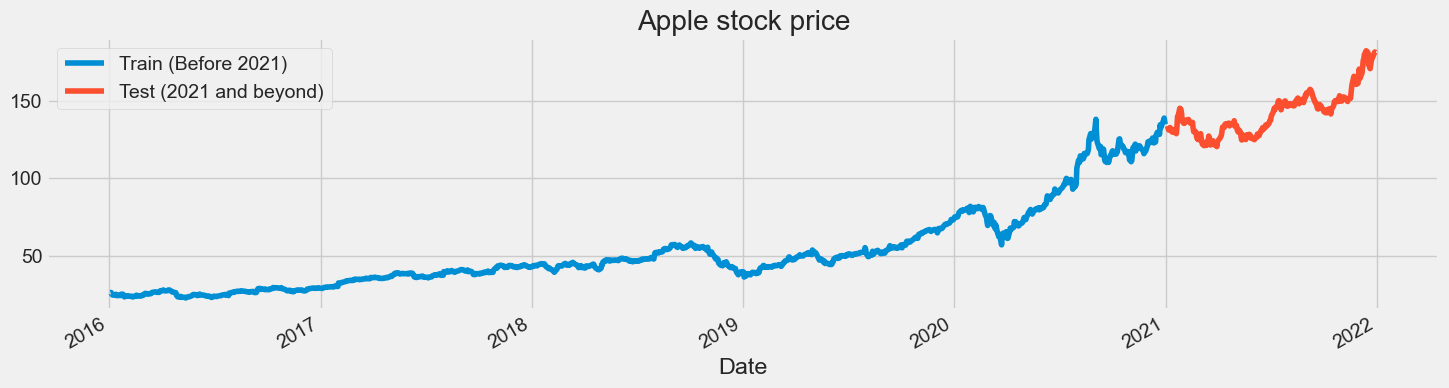

In [20]:
train_test_plot(dataset, tstart, tend)

### Creating train and test datasets

In [21]:
def train_test_split(dataset, tstart, tend, columns = ['High']):
    train = dataset.loc[f"{tstart}":f"{tend}", columns].values
    test = dataset.loc[f"{tend+1}":, columns].values
    return train, test

In [22]:
training_set, test_set = train_test_split(dataset, tstart, tend)

### Scaling dataset values

In [23]:
sc = MinMaxScaler(feature_range=(0, 1))
training_set = training_set.reshape(-1, 1)
training_set_scaled = sc.fit_transform(training_set)

### Creating overlapping window batches

In [24]:
n_steps = 1
features = 1

In [25]:
def split_sequence(sequence, n_steps):
    X, y = list(), list()
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1:
            break
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [26]:
X_train, y_train = split_sequence(training_set_scaled, n_steps)

In [27]:
# Reshaping X_train for model
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], features)

### Evaluation

In [28]:
def plot_predictions(test, predicted, title):
    plt.plot(test, color="gray", label="Real")
    plt.plot(predicted, color="red", label="Predicted")
    plt.title(f'{title}')
    plt.xlabel("Time")
    plt.ylabel(f'{title}')
    plt.legend()
    plt.show()

In [29]:
def return_rmse(test, predicted):
    rmse = np.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {:.2f}.".format(rmse))

### Vanilla RNN

In [30]:
def plot_loss(history):
    plt.figure(figsize = (15,10))
    plt.plot(history.history['loss'], label='loss')
    plt.legend(loc='best')
    plt.show()

In [31]:
model_rnn = Sequential()
model_rnn.add(SimpleRNN(units=125, input_shape=(n_steps, features)))
model_rnn.add(Dense(units=1))

In [32]:
# Compiling the model
model_rnn.compile(optimizer="RMSprop", loss="mse")

In [33]:
history = model_rnn.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

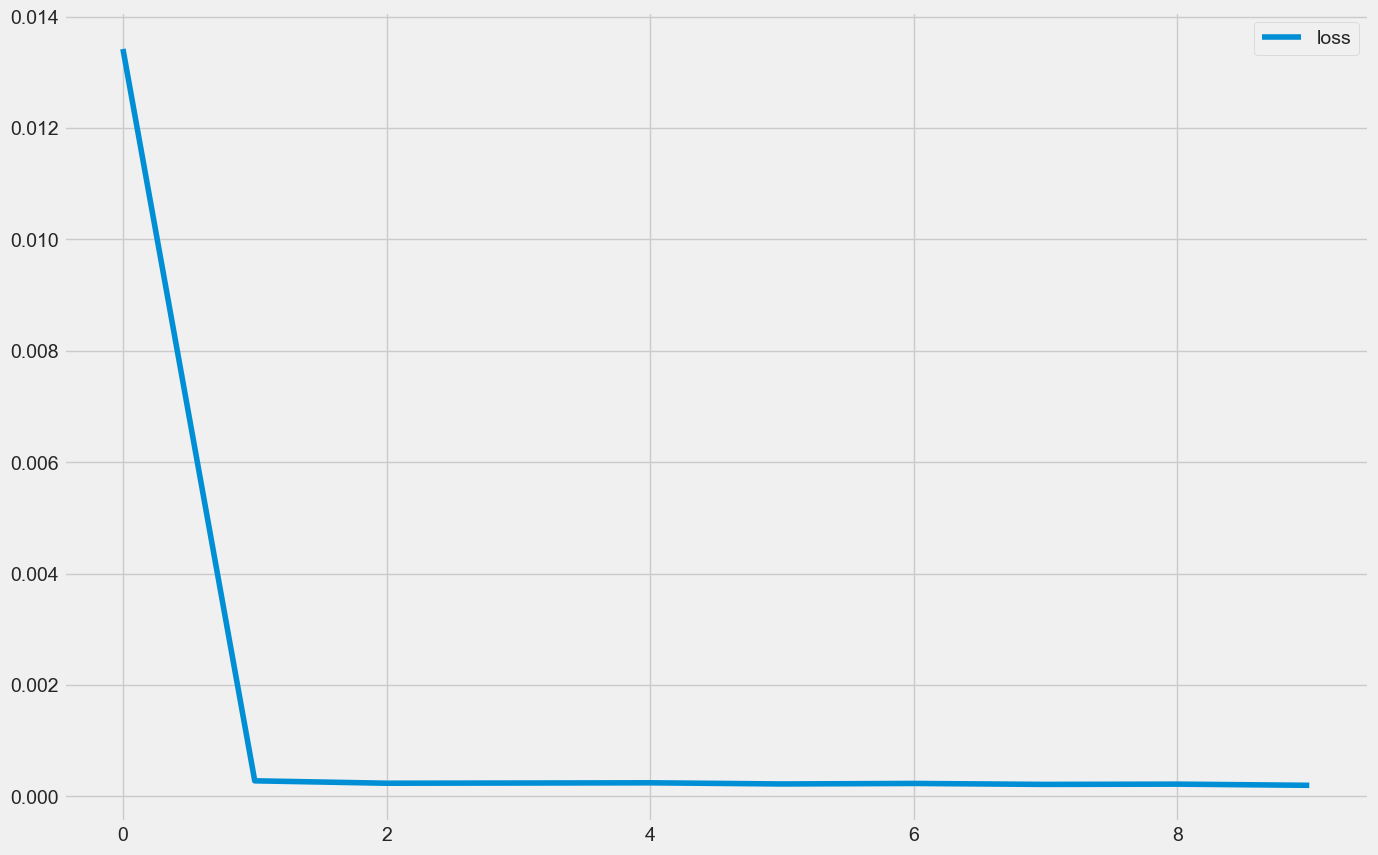

In [34]:
plot_loss(history)

In [35]:
# Scaling
inputs = sc.transform(test_set.reshape(-1, 1))

In [36]:
# Split into samples
X_test, y_test = split_sequence(inputs, n_steps)
# reshape
X_test = X_test.reshape(-1, n_steps, features)

In [37]:
# Prediction
predicted_stock_price = model_rnn.predict(X_test)
# Inverse transform the values
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 [==============================] - 0s 1ms/step


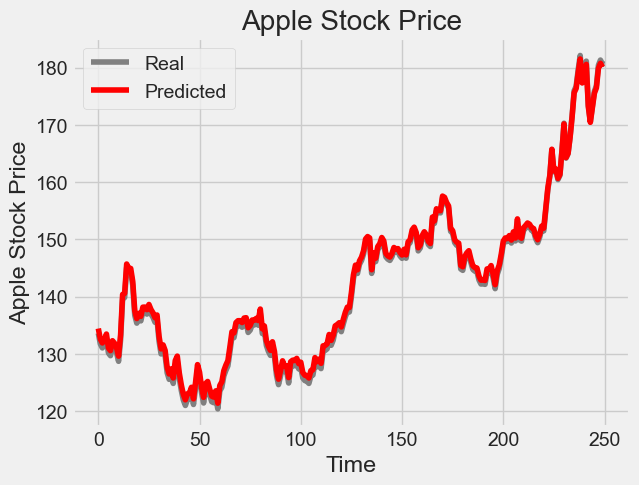

In [38]:
plot_predictions(test_set, predicted_stock_price, "Apple Stock Price")

### Sequence Generation

In [39]:
steps_in_future = 25

In [40]:
def sequence_generation(dataset: pd.DataFrame, sc: MinMaxScaler, model:Sequential, steps_future: int):
    high_dataset = dataset.iloc[len(dataset) - len(test_set) - n_steps:]["High"]
    high_dataset = sc.transform(high_dataset.values.reshape(-1, 1))
    inputs = high_dataset[:n_steps]

    for _ in range(steps_future):
        curr_pred = model.predict(inputs[-n_steps:].reshape(-1, n_steps, features), verbose=0)
        inputs = np.append(inputs, curr_pred, axis=0)

    return sc.inverse_transform(inputs[n_steps:])

In [41]:
results = sequence_generation(dataset, sc, model_rnn, steps_in_future)

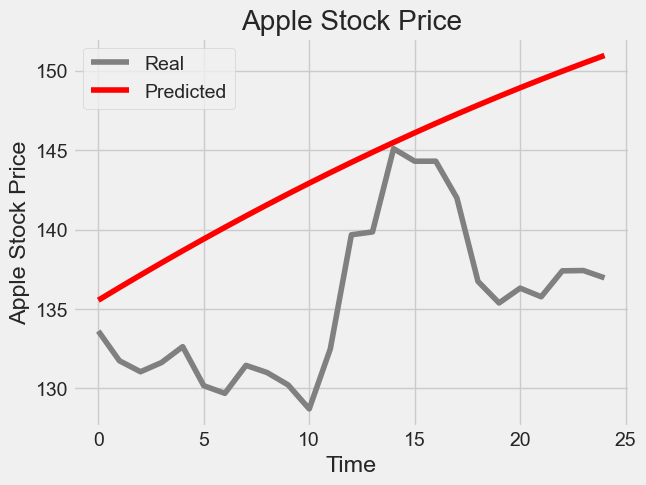

In [42]:
plot_predictions(test_set[:steps_in_future], results, "Apple Stock Price")

In [43]:
model_lstm = Sequential()
model_lstm.add(LSTM(units=125, input_shape=(n_steps, features)))
model_lstm.add(Dense(units=1))

In [44]:
# Compiling the model
model_lstm.compile(optimizer="RMSprop", loss="mse")

In [45]:
history = model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

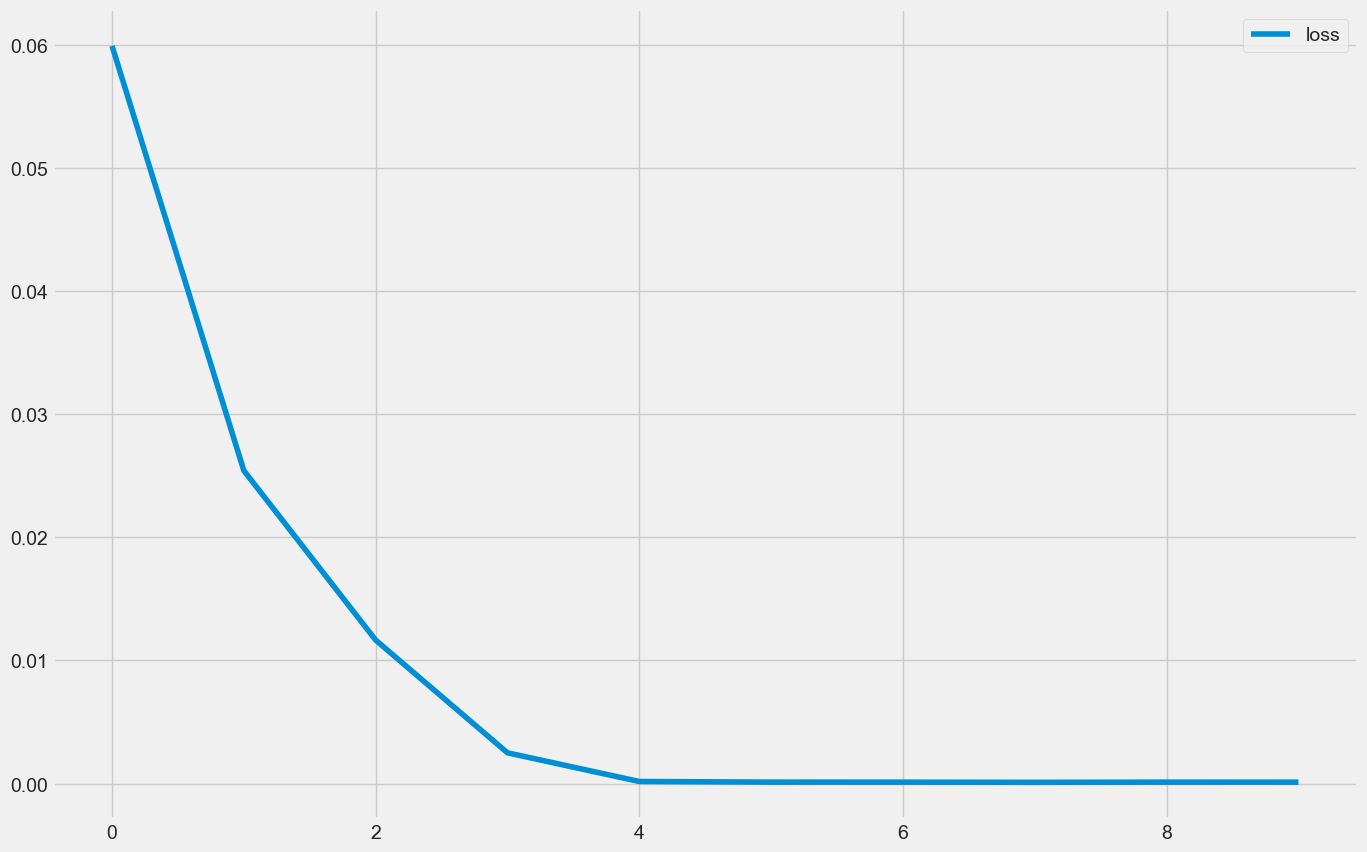

In [46]:
plot_loss(history)

In [47]:
#prediction
predicted_stock_price = model_lstm.predict(X_test)
#inverse transform the values
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 [==============================] - 0s 2ms/step


### Time Series Prediction: LSTM

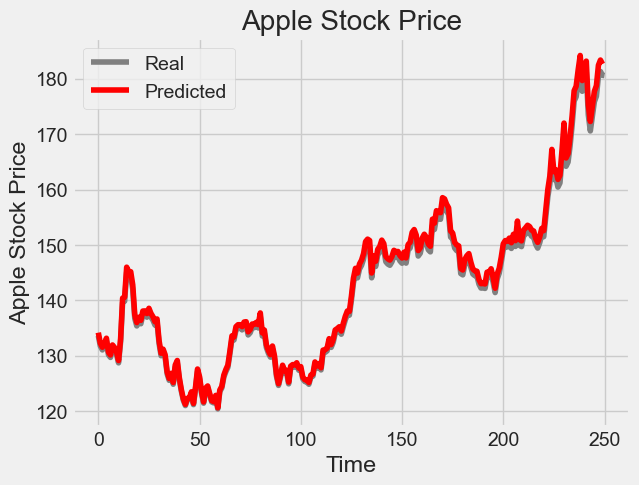

In [48]:
plot_predictions(test_set, predicted_stock_price, "Apple Stock Price")

### Sequence Generation: LSTM

In [49]:
results = sequence_generation(dataset, sc, model_lstm, steps_in_future)

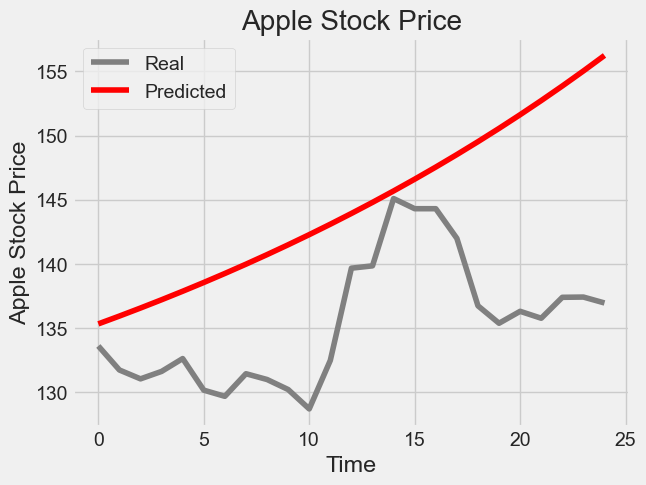

In [50]:
plot_predictions(test_set[:steps_in_future], results, "Apple Stock Price")

## Multivariate Input

RNN's can be used with several dimensions, like images. Each dimension will be a different time series. In here we calculate technical indicators that correlate with our stock price to predict **Gains**

In [51]:
mv_features = 6

In [52]:
multi_variate_df = dataset.copy()

### Creating Technical Indicators

**Relative Strength Index (RSI)**: The relative strength index (RSI) is a momentum indicator used in technical analysis. RSI measures the speed and magnitude of a security's recent price changes to evaluate overvalued or undervalued conditions in the price of that security.

**Exponential Moving Average (EMA)**: An exponential moving average (EMA) is a type of moving average (MA) that places a greater weight and significance on the most recent data points. The exponential moving average is also referred to as the exponentially weighted moving average. An exponentially weighted moving average reacts more significantly to recent price changes than a simple moving average simple moving average (SMA), which applies an equal weight to all observations in the period. Traders often use several different EMA lengths, such as 10-day, 50-day, and 200-day moving averages.

In [53]:
multi_variate_df['RSI'] = ta.rsi(multi_variate_df.Close, length=15)
multi_variate_df['EMAF'] = ta.ema(multi_variate_df.Close, length=20)
multi_variate_df['EMAM'] = ta.ema(multi_variate_df.Close, length=100)
multi_variate_df['EMAS'] = ta.ema(multi_variate_df.Close, length=150)

### Creating Labels

Labels are created by calculating the difference in closing price of share.

In [54]:
multi_variate_df['Target'] = multi_variate_df['Adj Close'] - dataset.Open
multi_variate_df['Target'] = multi_variate_df['Target'].shift(-1)
multi_variate_df.dropna(inplace=True)
multi_variate_df.drop(['Volume', 'Close'], axis=1, inplace=True)

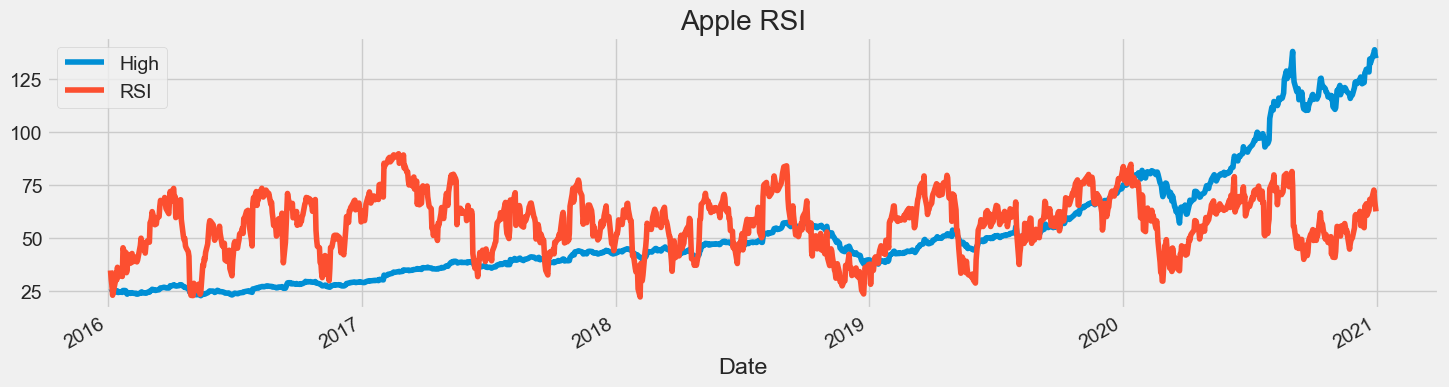

In [55]:
multi_variate_df.loc[f"{tstart}":f"{tend}", ['High', 'RSI']].plot(figsize=(16, 4), legend=True)
plt.title("Apple RSI")
plt.show()

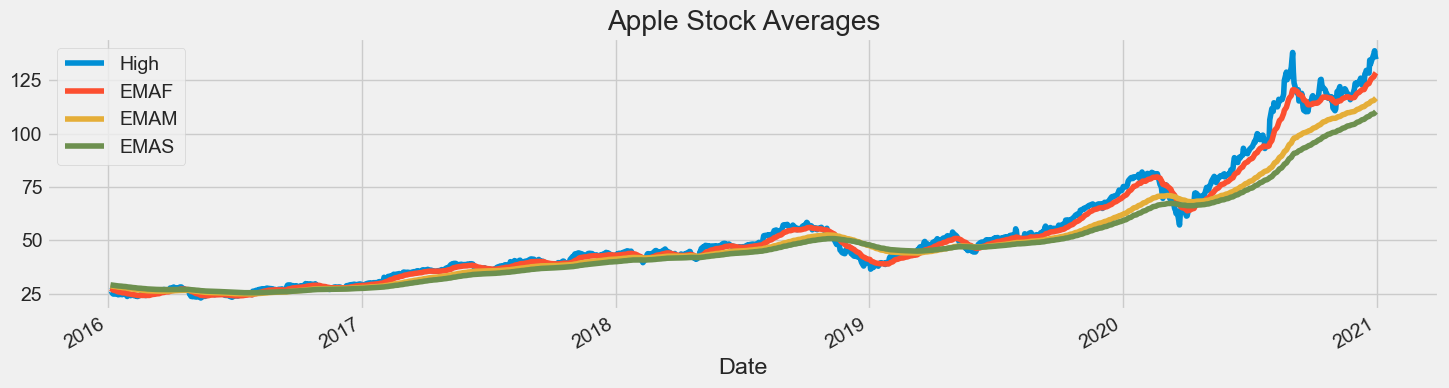

In [56]:
multi_variate_df.loc[f"{tstart}":f"{tend}", ['High', 'EMAF', 'EMAM', 'EMAS']].plot(figsize=(16, 4), legend=True)
plt.title("Apple Stock Averages")
plt.show()

In [57]:
feat_columns = ['Open', 'High', 'RSI', 'EMAF', 'EMAM', 'EMAS']
label_col = ['Target']

### Splitting train and test data

In [58]:
mv_training_set, mv_test_set = train_test_split(multi_variate_df, tstart, tend, feat_columns + label_col)

In [59]:
X_train = mv_training_set[:, :-1]
y_train = mv_training_set[:, -1]

X_test = mv_test_set[:, :-1]
y_test = mv_test_set[:, -1]

### Scaling Data

In [60]:
mv_sc = MinMaxScaler(feature_range=(0, 1))
X_train = mv_sc.fit_transform(X_train).reshape(-1, 1, mv_features)
X_test = mv_sc.transform(X_test).reshape(-1, 1, mv_features)

### Model

In [61]:
model_mv = Sequential()
model_mv.add(LSTM(units=125, input_shape=(1, mv_features)))
model_mv.add(Dense(units=1))
# Compiling the model
model_mv.compile(optimizer="RMSprop", loss="mse")

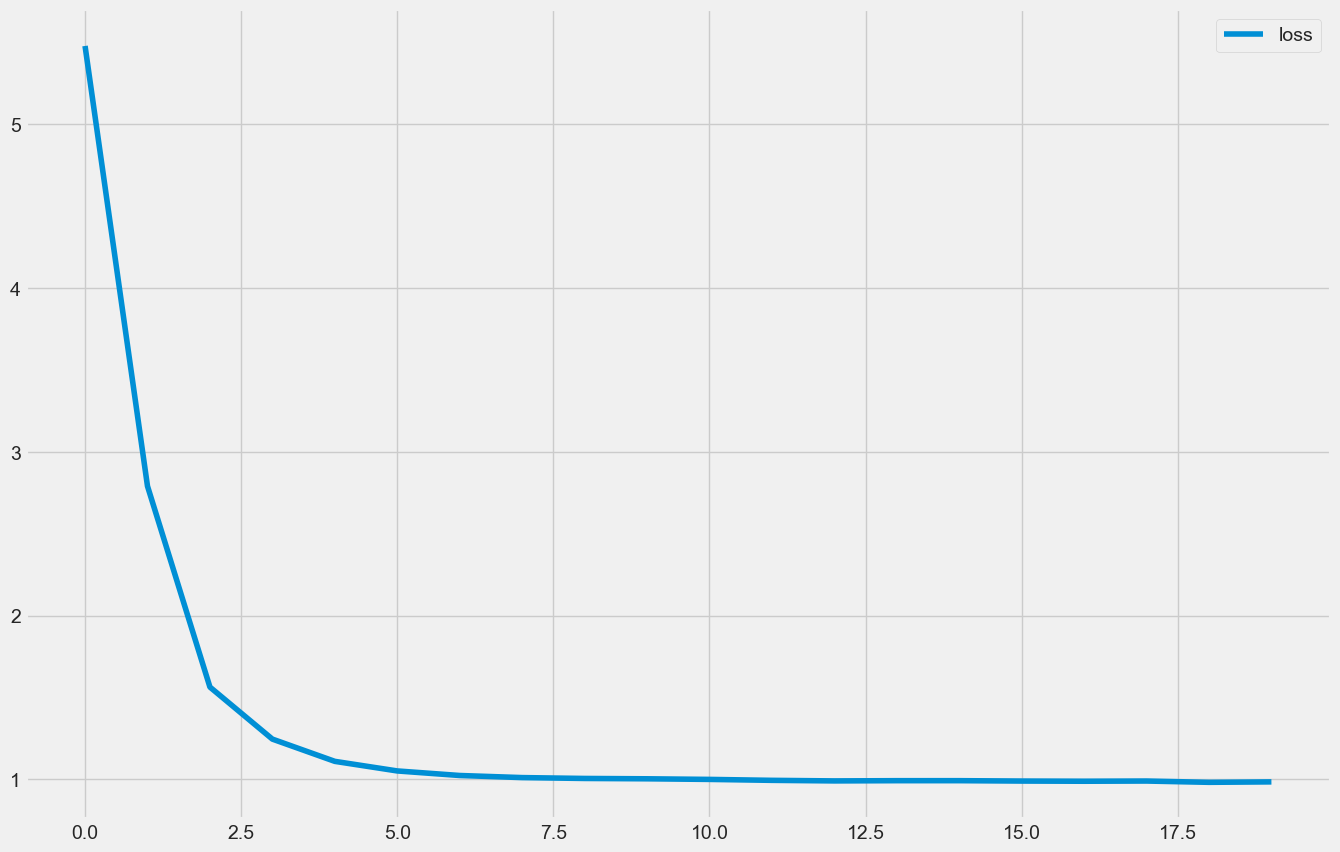

In [62]:
history = model_mv.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)
plot_loss(history)

### Results

8/8 [==============================] - 0s 2ms/step


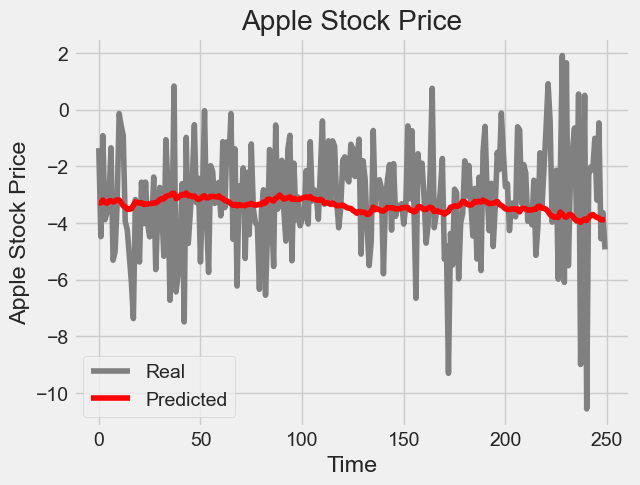

In [63]:
predictions = model_mv.predict(X_test)
plot_predictions(y_test, predictions, "Apple Stock Price")